<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# TS1: Síntesis y operaciones de señales
#### Sofía Makkos


En este trabajo se diseñarán 5 tipos de señales (más una extra), siendo estas de funciones, frecuencias y potencias distintas. En todas ellas, se utilizará la misma cantidad de muestras N=1000.

Se utilizarán las siguientes librerías:

In [1]:
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.signal import square
import matplotlib.pyplot as plt

N=1000

#### 1° señal: 
Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.

20000


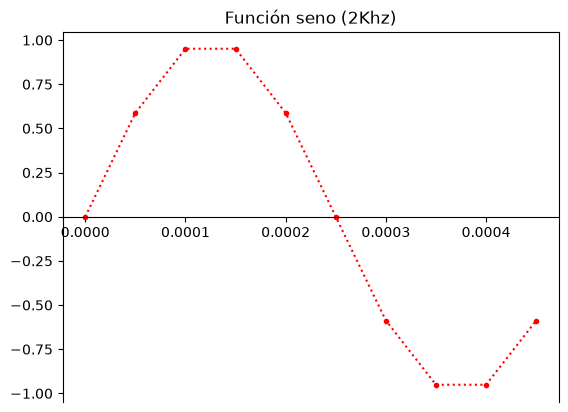

In [2]:
fs=20000

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    tt=np.arange(0.0, N/fs, 1/fs)
    xx=vmax*np.sin(2*np.pi*ff*tt +ph)+dc
    return(tt, xx)
tt, xx= mi_funcion_sen(ff=2000)

print(fs)

plt.figure(1)
plt.plot(tt[:10],xx[:10], ":.", color="red")
plt.title("Función seno (2Khz)")
plt.gca().spines['bottom'].set_position('zero')

Utilicé la función seno originada en el TS0 para simplificación de cuentas. Para que la señal sinusoidal disponga de una frecuencia de 2kHz, se le indicó este valor (2000) a la variable *ff*.
Por otro lado, se buscó que la función tenga por lo menos 10 puntos por período. Para eso, se tuvo en cuenta la siguiente relación:
\begin{equation}
T=\frac{M}{fs}=\frac{1}{ff} \Longrightarrow M*fs=ff
\end{equation}
*M* siendo la cantidad de puntos por período y *fs* la frecuencia de muestreo. Es así, que determinamos que *fs*=20000.
Por otro lado, para mejor ilustración, al momento de graficar la función, se decidió que que en la función *plt.plot* se tomen valores temporales y espaciales que indiquen un solo período realizado.

Text(0.5, 1.0, 'Seno en dB  (2kHz)')

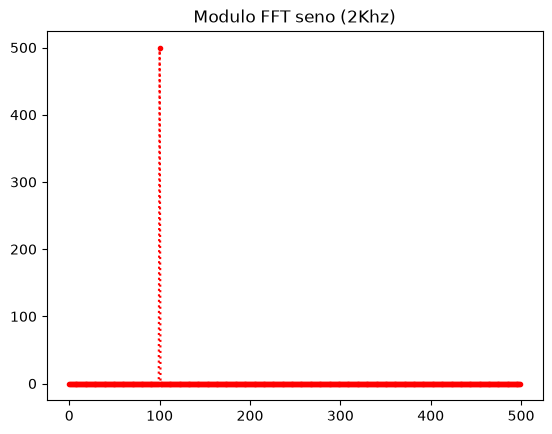

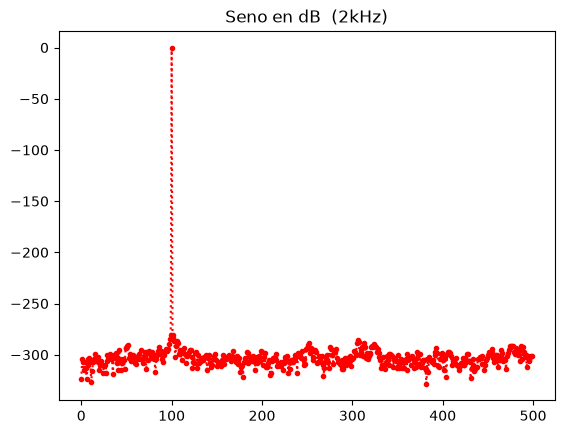

In [7]:
fftxx = fft(xx)
fftxx = fftxx[:N//2]
freq = fftfreq(N,1/fs)
freq = freq[:N//2]
fftxx_abs = np.abs(fftxx)

plt.figure(2)
plt.plot(freq,fftxx_abs, ":.", color="red")
plt.title("Modulo FFT seno (2Khz)")

ref=np.max(fftxx_abs)
fftxx_abs_dB=20*np.log10(fftxx_abs/ref)

plt.figure(3)
plt.plot(freq, fftxx_abs_dB, ":.", color="red")
plt.title("Seno en dB  (2kHz)")

Posteriormente, se calculó el Fast Fourier Transform de la función seno, se tomó la primera mitad de sus valores absolutos, y se creó una frecuencia *freq* acorde con los valores utilizados, para realizar el gráfico correspondiente.

También se realizó el gráfico 

#### 2° señal: 
Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período, con 2 W de potencia media y desfasada en π/2.

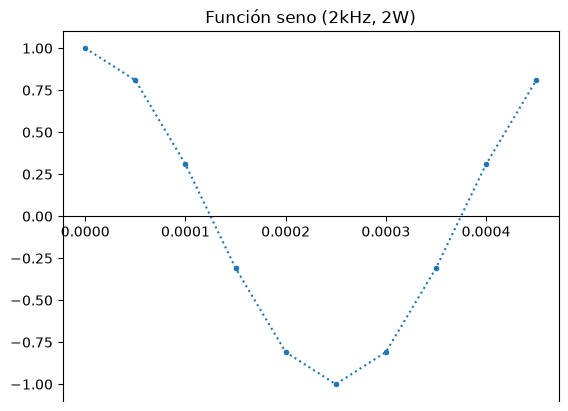

In [4]:
tt, xx= mi_funcion_sen(ff=2000, ph=np.pi/2)

plt.figure(3)
plt.plot(tt[:10],xx[:10], ":.")
plt.title("Función seno (2kHz, 2W)")
plt.gca().spines['bottom'].set_position('zero')

Para la segunda señal se emplaron las mismas ideas que en la anterior, con respecto a la frecuencia y la cantidad de muestras por período.
En cuanto a la potencia media, se correspondió a la siguiente fórmula (válida para señales sinusoidales):
\begin{equation}
P_{media}=\frac{1}{N}*\sum_{n=0}^{N-1} x^2=\frac{a^2}{2} 
\end{equation}

Como se requiere de una potencia media de 2W, se deduce de la fórmula que *a*=2, lo cual se puede apreciar en la figura de la función a partir de la amplitud.

También, el enunciado indicó un desfasaje de $\frac{\pi}{2}$, así que en la función *mi_funcion_sen* se cambió el valor del parámetro *ph*

Se puede comparar entonces las dos funciones elaboradas hasta ahora. Cuentan con misma frecuencia y cantidad de puntos por período, sin embargo, la amplitud de la segunda sinusoidal se duplica en comparación a la primera, a la vez que la ordenada del origen se ve modificada por el desfasaje.

Text(0.5, 1.0, 'Modulo FFT seno (2kHz, 2W)')

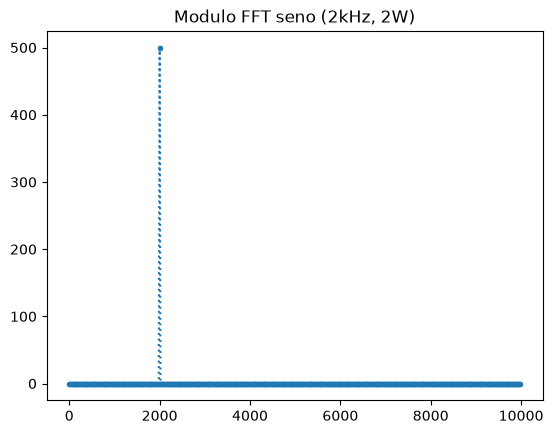

In [5]:
fs=20000
fftxx = fft(xx)
fftxx = fftxx[:N//2]
#print(fftxx[k])
freq = fftfreq(N,1/fs)
freq = freq[:N//2]
fftxx_abs = np.abs(fftxx)

plt.figure(4)
plt.plot(freq,fftxx_abs, ":.")
plt.title("Modulo FFT seno (2kHz, 2W)")

SOLO DEPENDE DE FS Y FF, DAR EJEMPLO CON OTRO FF

#### 3° Señal:
Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.


([], [])

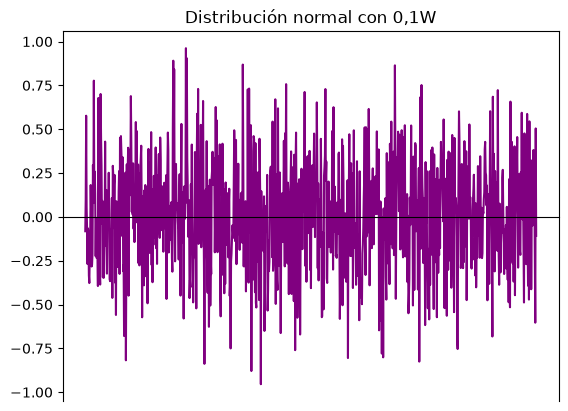

In [6]:
tt=np.arange(N)
fs=1000
norm=np.random.normal(scale=np.sqrt(0.1),size=len(tt))
pnorm=np.var(norm)

plt.figure(5)
plt.plot(tt, norm, color="purple")
plt.title("Distribución normal con 0,1W")
plt.gca().spines['bottom'].set_position('zero')
plt.xticks([], [])